# Выявление рисков в доставке компании CargaPronto

CargaPronto — логистический оператор, связывающий производственные хабы Пуэрто-Рико с потребителями в США. По результатам внутреннего аудита 55% заказов доставляются с задержкой, штрафы за нарушение SLA превысили бюджет на IT-инфраструктуру, крупные ритейлеры угрожают расторжением контрактов.

Департамент транспорта считает, что причина задержек — не в логистике, а в неоднородности клиентской базы (труднодоступная география, клиенты с высокой долей возвратов/отмен и т.д.).

**Гипотеза для проверки:** задержки связаны со спецификой профиля клиента, и если сегментировать базу (по географии и поведению), можно предсказывать риск задержки уже в момент оформления заказа.

- **Тип задачи:** бинарная классификация.
- **Модели:**
  - Логистическая регрессия — для оценки «нижней планки» качества, ценится за скорость и прозрачность.
  - CatBoostClassifier — градиентный бустинг для поиска сложных закономерностей.
- **Метрика качества:** ROC-AUC (оценивает способность ранжировать заказы по риску).
- **Целевой порог:** ROC-AUC > 0.75 на тестовой выборке считается удовлетворительным результатом.

Данные:

Профили клиентов:

| Признак | Описание |
|---|---|
| `customer_id` | уникальный ID клиента, ключ для связи с orders |
| `customer_lat` | широта местонахождения клиента |
| `customer_lon` | долгота местонахождения клиента |
| `recency` | дней с момента последнего заказа (RFM: Recency) |
| `total_orders` | общее количество заказов (RFM: Frequency) |
| `total_sales` | суммарная выручка от клиента (RFM: Monetary) |
| `avg_discount` | средний размер скидки клиента |
| `return_rate` | доля проблемных заказов (возвраты/отмены) |

Таблица заказов:

| Признак | Описание |
|---|---|
| `order_id` | уникальный номер заказа |
| `customer_id` | ключ для связи с customers |
| `order_date` | дата и время покупки |
| `category_name` | категория товара |
| `item_price` | стоимость товара |
| `shipping_mode` | режим доставки (Standard Class, First Class, Second Class, Same Day) |
| `late_delivery_risk` | **целевая переменная**: 1 — задержка, 0 — доставлено вовремя |

##  Импорт библиотек, выполнение базовых настроек

Загрузите все необходимые для выполнения проекта библиотеки и другие компоненты.



In [1]:
%pip install -q -r requirements.txt

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import phik
import optuna
import shap

## Загрузка данных, первичное знакомство

- Загрузим датасеты `ds_s18_customers.csv` и `ds_s18_orders.csv` (пути: `'/datasets/ds_s18_customers.csv'` и `'/datasets/ds_s18_orders.csv'`).
- Затем проводем технический аудит данных.
- Выявим и устраним полные дубликаты строк.
- Выполним проверку целостности данных (ID-Check).
- Подготовим признаки, связанные с датой и временем.
- Создадим дополнительные колонки: `order_month`, `order_weekday`, `order_hour`.


In [3]:
from dotenv import load_dotenv
import os

load_dotenv()

FILES_URL = os.getenv('FILES_URL')

In [ ]:
# Random state
RANDOM_STATE=1703

TARGET_COL='late_delivery_risk'

In [88]:
def get_data():
    try:
        df_c = pd.read_csv('./datasets/ds_s18_customers.csv')
        df_o = pd.read_csv('./datasets/ds_s18_orders.csv')
        print('Файлы загружены из кеша')
    except Exception as e:
        df_c = pd.read_csv(FILES_URL + '/datasets/ds_s18_customers.csv')
        df_o = pd.read_csv(FILES_URL + '/datasets/ds_s18_orders.csv')

        df_c.to_csv('./datasets/ds_s18_customers.csv', index=False)
        df_o.to_csv('./datasets/ds_s18_orders.csv', index=False)

        print('Файлы загружены из сети')
    
    return df_c, df_o


In [92]:
df_c, df_o = get_data()

Файлы загружены из кеша


In [7]:
df_c.head()

,customer_id,customer_lat,customer_lon,total_sales,total_orders,avg_discount,return_rate,recency
0,1,25.953648,-97.507683,472.450012,1,0.060,0.0,793
1,2,38.375595,-104.726021,1618.660042,4,0.126,0.0,137
2,3,18.025375,-66.615082,3189.200037,5,0.105,0.0,230
3,4,33.670021,-112.247078,1480.709993,4,0.135,0.0,381
4,5,18.359104,-66.077911,1101.919998,3,0.140,0.0,458


In [8]:
df_o.head()

,order_id,customer_id,late_delivery_risk,shipping_mode,category_name,order_date,item_price
0,180517,20755,0,Standard Class,Sporting Goods,2018-01-31 22:56:00,327.75
1,179254,19492,1,Standard Class,Sporting Goods,2018-01-13 12:27:00,327.75
2,179253,19491,0,Standard Class,Sporting Goods,2018-01-13 12:06:00,327.75
3,179252,19490,0,Standard Class,Sporting Goods,2018-01-13 11:45:00,327.75
4,179251,19489,0,Standard Class,Sporting Goods,2018-01-13 11:24:00,327.75


**Промежуточный вывод**

Таблицы успешно загружены. Переходим к предподготовке данных

In [9]:
# Вывод информации о датасете
df_c.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20652 entries, 0 to 20651
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   customer_id   20652 non-null  int64  
 1   customer_lat  20652 non-null  float64
 2   customer_lon  20652 non-null  float64
 3   total_sales   20652 non-null  float64
 4   total_orders  20652 non-null  int64  
 5   avg_discount  20652 non-null  float64
 6   return_rate   20652 non-null  float64
 7   recency       20652 non-null  int64  
dtypes: float64(5), int64(3)
memory usage: 1.3 MB


In [10]:
# Вывод информации о датасете
df_o.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180519 entries, 0 to 180518
Data columns (total 7 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   order_id            180519 non-null  int64  
 1   customer_id         180519 non-null  int64  
 2   late_delivery_risk  180519 non-null  int64  
 3   shipping_mode       180519 non-null  object 
 4   category_name       180519 non-null  object 
 5   order_date          180519 non-null  object 
 6   item_price          180519 non-null  float64
dtypes: float64(1), int64(3), object(3)
memory usage: 9.6+ MB


In [11]:
# Проверка на наличие пропусков с использованием assert
assert not df_c.isnull().any().any(), 'В таблице customers найдены пропуски'
assert not df_o.isnull().any().any(), 'В таблице orders найдены пропуски'

In [12]:
# Проверка на наличие полных дубликатов строк с использованием assert
assert not df_c.duplicated().any(), 'В таблице customers найдены полные дубликаты строк'
assert not df_o.duplicated().any(), 'В таблице orders найдены полные дубликаты строк'

In [13]:
# Проверка на наличие дубликатов id
assert not df_o['order_id'].duplicated().any(), 'В таблице orders найдены дубликаты id заказов'
assert not df_c['customer_id'].duplicated().any(), 'В таблице customers найдены дубликаты id клиентов'

In [14]:
# Проверка на наличие пропусков в объединенном датасете
assert set(df_o['customer_id']) - set(df_c['customer_id']) == set(), 'В заказах есть клиенты, которые не зарегистрированы в таблице customers'
assert set(df_c['customer_id']) - set(df_o['customer_id']) == set(), 'В таблице customers есть клиенты, которые не появились в таблице orders'


**Промежуточный вывод**

Для полной корректности типов требуется преобразовать тип признака `order_date` в таблице заказов к `datetime`

В данных не обнаружено пропусков

В данных не обнаружено полных дубликатов строк и дубликатов id заказов

В данных не выявлено проблем с целостностью. Таблицы клиентов и заказов можно соединить без пропусков

In [15]:
# Функция для подготовки данных о заказах
def prepare_orders_data(df_o):
    # Преобразование даты в datetime
    df_o['order_date'] = pd.to_datetime(df_o['order_date'])

    # Создание новых признаков
    df_o['order_month'] = df_o['order_date'].dt.month
    df_o['order_weekday'] = df_o['order_date'].dt.weekday
    df_o['order_hour'] = df_o['order_date'].dt.hour

    return df_o

In [16]:
# Применение функции подготовки данных о заказах
df_o = prepare_orders_data(df_o)
df_o.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180519 entries, 0 to 180518
Data columns (total 10 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   order_id            180519 non-null  int64         
 1   customer_id         180519 non-null  int64         
 2   late_delivery_risk  180519 non-null  int64         
 3   shipping_mode       180519 non-null  object        
 4   category_name       180519 non-null  object        
 5   order_date          180519 non-null  datetime64[ns]
 6   item_price          180519 non-null  float64       
 7   order_month         180519 non-null  int32         
 8   order_weekday       180519 non-null  int32         
 9   order_hour          180519 non-null  int32         
dtypes: datetime64[ns](1), float64(1), int32(3), int64(3), object(2)
memory usage: 11.7+ MB


**Промежуточный вывод**

Для подготовки признаков в таблице заказов создана функция. Она приводит признак с датой заказа к корректному типу и выделяет из даты месяц, день недели и час

Можем переходить к EDA

## EDA

На этом этапе цель — исследовать структуру данных и подтвердить гипотезы транспортного департамента о «неоднородности» базы. Кроме того, изучим и удалим географические аномалии.


### Проверка баланса классов

В задаче заявлено, что задержек 55%. Проверим эту информацию:

In [17]:
# Доля задержек
df_o[TARGET_COL].value_counts(normalize=True)

late_delivery_risk
1    0.548291
0    0.451709
Name: proportion, dtype: float64

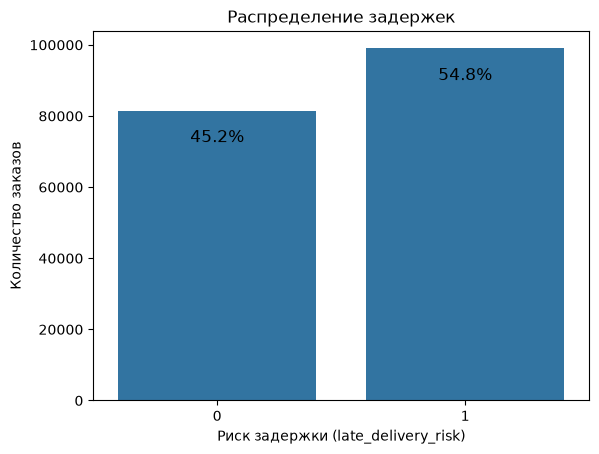

In [18]:
# График распределения задержек
ax = sns.countplot(x=TARGET_COL, data=df_o)
plt.title('Распределение задержек')
plt.xlabel('Риск задержки (late_delivery_risk)')
plt.ylabel('Количество заказов')

# Добавим на график процент каждого класса
total = len(df_o)
for p in ax.patches:
    ax.annotate(
        f"{100 * int(p.get_height()) / total:.1f}%",
        (p.get_x() + p.get_width() / 2, p.get_height() - 10000),
        ha='center', va='bottom', fontsize=12
    )

plt.show()

**Промежуточный вывод**

Баланс целевого класса подтвержден. Задержек примерно 55%

### Географический аудит

Построим диаграмму рассеяния координат клиентов и изучить выбросы

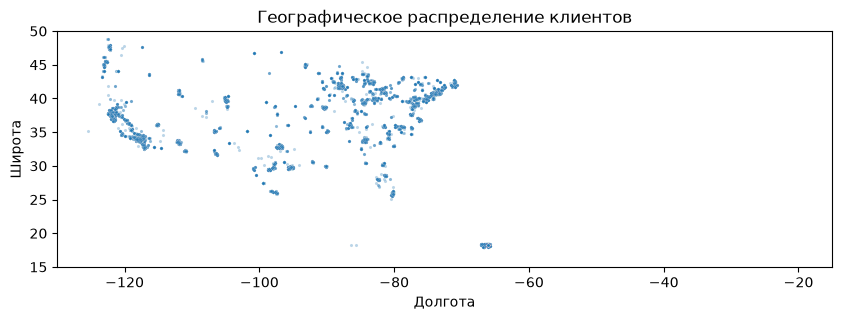

In [19]:
# Диаграмма рассеяния координат заказов
plt.figure(figsize=(10, 6))
sns.scatterplot(x='customer_lon', y='customer_lat', data=df_c, s=5, alpha=0.3)
plt.xlim(-130, -15)
plt.ylim(15, 50)
plt.xlabel('Долгота')
plt.ylabel('Широта')
plt.title('Географическое распределение клиентов')
plt.gca().set_aspect('equal', adjustable='box')
plt.show()

В дополнение к диаграмме построим карту с помощью библиотеки folium

In [83]:
import folium

def get_map(df_c, n_points=1000):
    df_plot = df_c
    if len(df_c) > n_points:
        df_plot = df_c.sample(n=n_points, random_state=RANDOM_STATE)

    m = folium.Map(
        location=[df_c['customer_lat'].median(), df_c['customer_lon'].median()],
        zoom_start=2,
        tiles='OpenStreetMap',
        zoom_control=False,
        scrollWheelZoom=False,
        dragging=False,
        doubleClickZoom=False,
        boxZoom=False,
        touchZoom=False,
        attributionControl=False,
    )

    for lat, lon in df_plot[['customer_lat', 'customer_lon']].values:
        folium.CircleMarker(
            location=[lat, lon],
            radius=2,
            color='steelblue',
            fill=True,
            fill_opacity=0.5,
        ).add_to(m)

    folium.PolyLine(
        locations=[[0, -125], [60, -125]],  # [lat, lon]
        color="red",
        weight=2,
        opacity=0.8,
    ).add_to(m)

    folium.PolyLine(
        locations=[[0, -20], [60, -20]],
        color="red",
        weight=2,
        opacity=0.8,
    ).add_to(m)

    return m

get_map(df_c)


### Удаление аномалий

На карте замечено небольшое количество аномалий. Это точки с долготой (lon) выходящей за границы [-125, -20]. Пользователей с такими координатами необходимо удалить вместе с их заказами:


In [21]:
# Функция для удаления аномалий
def remove_anomalies(df_c, df_o):
    df_c_clean = df_c[df_c['customer_lon'].between(-125, -20)].copy()
    df_o_clean = df_o[df_o['customer_id'].isin(df_c_clean['customer_id'])].copy()

    return df_c_clean, df_o_clean


In [22]:
# Применение функции для удаления аномалий
df_c_before, df_o_before = len(df_c), len(df_o)
df_c, df_o = remove_anomalies(df_c, df_o)
print(f"Удалено клиентов: {df_c_before - len(df_c)}")
print(f"Удалено заказов: {df_o_before - len(df_o)}")

Удалено клиентов: 156
Удалено заказов: 1430


In [84]:
# Вывод пользователей на карте после удаления аномалий
get_map(df_c)

### Зависимости между признаками

Рассчитаем зависимости в таблице товаров. Перед расчетом удалим из таблицы признаки, значения которых почти всегда будут уникальными и не несут полезной информации для модели `order_id`, `customer_id` и `order_date`


In [24]:
# Функция для построения тепловой карты
def heatmap(df):
    plt.figure(figsize=(15, 10))

    sns.heatmap(
        df,
        cmap="coolwarm",
        vmin=0, vmax=1,
        annot=True, fmt=".2f",
        linewidths=0.5,
        square=True,
        cbar_kws={"shrink": 0.8}
    )

    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)

    plt.title("Phik Correlation Matrix", fontsize=16)
    plt.show()

In [26]:
# Расчет корреляции между признаками
df_o_phik = df_o.drop(columns=['order_id', 'customer_id', 'order_date']).phik_matrix(
    ['late_delivery_risk', 'item_price', 'order_month', 'order_weekday', 'order_hour']
)

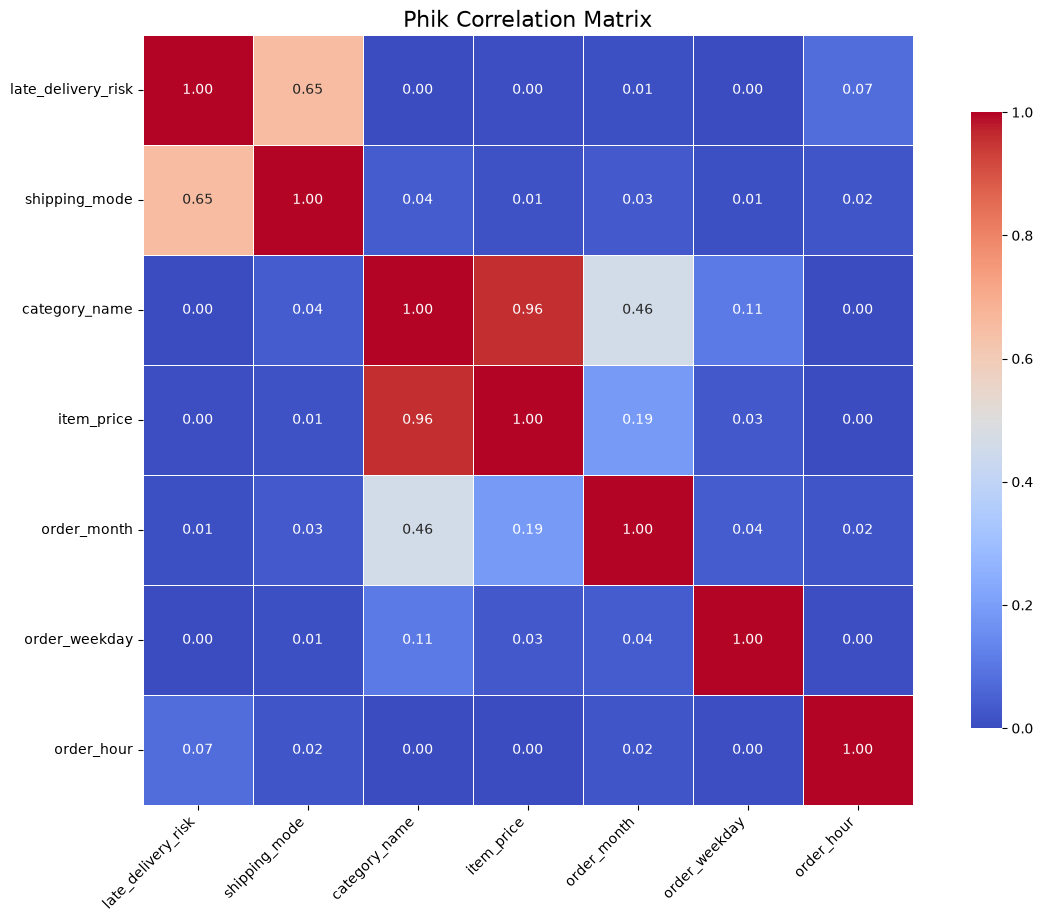

In [27]:
heatmap(df_o_phik)

In [28]:
df_o_phik[TARGET_COL].drop(TARGET_COL).sort_values(ascending=False)

shipping_mode    0.653699
order_hour       0.074537
order_month      0.008065
item_price       0.004763
order_weekday    0.001739
category_name    0.000000
Name: late_delivery_risk, dtype: float64

**Промежуточный вывод**

Связь признаков с целевой переменной `late_delivery_risk`:
- самый сильный сигнал даёт `shipping_mode` (φk ≈ 0.65) — режим доставки заметно связан с риском задержки;
- временные признаки связаны слабо: `order_hour` ≈ 0.07, `order_weekday` ≈ 0.002, `order_month` ≈ 0.008;
- `item_price` почти не связан с целевой (≈ 0.004), `category_name` — связи нет (≈ 0.00).

Вывод: одних признаков заказа недостаточно для сильного прогноза — кроме `shipping_mode`, полезный сигнал слабый. Это согласуется с гипотезой проекта: для роста качества нужны признаки профиля клиента (география и поведение), которые будут получены на этапах кластеризации.


##  Разделение на выборки

Разделим датафрейм с заказами на выборки. Но используем не `train_test_split`, а `GroupShuffleSplit`. Он делит данные так, чтобы группы, то есть клиенты, не пересекались.

1. Разделим данные из датафрейма с заказами на три выборки в соотношении 60:20:20.

2. После разделения обязательно убедимся, что множества ID клиентов в `train`, `val` и `test` не пересекаются. Если один и тот же клиент попал в разные выборки, то разделение выполнено неверно.

In [29]:
from sklearn.model_selection import GroupShuffleSplit

# Функция для проверки пересечения множеств ID клиентов в выборках
def assert_no_overlap(df_train, df_val, df_test):
    assert set(df_train['customer_id']).isdisjoint(df_val['customer_id']), "Ошибка: Есть пересечение клиентов между train и val выборками!"
    assert set(df_train['customer_id']).isdisjoint(df_test['customer_id']), "Ошибка: Есть пересечение клиентов между train и test выборками!"
    assert set(df_val['customer_id']).isdisjoint(df_test['customer_id']), "Ошибка: Есть пересечение клиентов между val и test выборками!"

# Функция для разделения данных о заказах на выборки
def split_orders(df_o):
    groups = df_o['customer_id']
    # temp (80%) and test (20%)
    gss1 = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=RANDOM_STATE)
    temp_idx, test_idx = next(gss1.split(df_o, groups=groups))
    df_temp = df_o.iloc[temp_idx]
    df_test = df_o.iloc[test_idx]

    # temp into train (60%) and val (20%)
    groups_temp = df_temp['customer_id']
    gss2 = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=RANDOM_STATE)
    train_idx, val_idx = next(gss2.split(df_temp, groups=groups_temp))
    df_train = df_temp.iloc[train_idx]
    df_val = df_temp.iloc[val_idx]

    assert_no_overlap(df_train, df_val, df_test)

    return df_train, df_val, df_test


In [30]:
df_o_train, df_o_val, df_o_test = split_orders(df_o)

In [79]:
# Проверка размеров выборок
sizes = pd.DataFrame({
    'orders': [len(df_o_train), len(df_o_val), len(df_o_test)],
    'customers': [
        df_o_train['customer_id'].nunique(),
        df_o_val['customer_id'].nunique(),
        df_o_test['customer_id'].nunique(),
    ],
}, index=['train', 'val', 'test'])
sizes['orders_share'] = (sizes['orders'] / len(df_o)).round(3)
sizes['customers_share'] = (sizes['customers'] / df_o['customer_id'].nunique()).round(3)
sizes

,orders,customers,orders_share,customers_share
train,108095,12297,0.604,0.6
val,35719,4099,0.199,0.2
test,35275,4100,0.197,0.2


**Промежуточный вывод**

Заказы разделены на train / val / test через `GroupShuffleSplit` по `customer_id`: доли близки к 60:20:20, множества клиентов не пересекаются (проверено `assert`).

Такое разделение исключает утечку: один клиент целиком попадает только в одну выборку, поэтому модель не может «узнать» его по адресу и привычкам.

## Обучение базовой модели

Прежде чем проверять гипотезу о сегментации и создавать при помощи кластеризации новые признаки, необходимо зафиксировать точку отсчёта. Нам нужно понять, какое качество прогноза задержек обеспечивают стандартные модели, используя только базовую информацию о самом заказе.

1. Выберем нужные признаки — используем колонки таблицы `orders` (`shipping_mode`, `category_name`, `item_price`, `order_hour`,  `order_weekday` и `order_month`).

2. Инициализируем пайплайны для логистической регрессии и `CatBoostClassifier`.

3. Подберем гиперпараметры для моделей

4. Обучим лучшие варианты моделей.

5. Оценим качество обеих моделей на валидационной выборке.

In [31]:
# Подготовка выборок для обучения моделей
num_cols = np.array(['item_price', 'order_hour', 'order_weekday', 'order_month'])
cat_cols = np.array(['shipping_mode', 'category_name'])
cols = np.concatenate([num_cols, cat_cols])

X_train = df_o_train[cols]
y_train = df_o_train[TARGET_COL]

X_val = df_o_val[cols]
y_val = df_o_val[TARGET_COL]


In [32]:
# Подготовка пайплайна для lr модели
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

def add_preprocessor_to_lr(model, num_cols, cat_cols):
    return Pipeline([
        ('preprocessor', ColumnTransformer([
                ('num', StandardScaler(), num_cols),
                ('ohe', OneHotEncoder(handle_unknown='ignore'), cat_cols),
            ])
        ),
        ('model', model)
    ])


In [33]:
# Функция для запуска исследования
def run_study(objective):
    study = optuna.create_study(
        direction="maximize",
        sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE),
    )

    study.optimize(objective, n_trials=30, show_progress_bar=True)

    return study

In [34]:
# Подготовка поиска гиперпараметров для lr модели
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

lr_default_params = {
    'solver': 'saga',
    'penalty': 'elasticnet',
    'class_weight': 'balanced',
    'random_state': RANDOM_STATE,
}

def objective_lr(X_train, y_train, X_val, y_val, num_cols, cat_cols):
    def objective(trial: optuna.trial.Trial) -> dict:
        params = {
            'C': trial.suggest_float('C', 0.01, 100),
            'l1_ratio': trial.suggest_float('l1_ratio', 0, 1),
            **lr_default_params,
        }

        model = add_preprocessor_to_lr(
            LogisticRegression(**params),
            num_cols=num_cols,
            cat_cols=cat_cols,
        )

        model.fit(X_train, y_train)

        return roc_auc_score(y_val, model.predict_proba(X_val)[:, 1])

    return objective


In [35]:
# Подготовка поиска гиперпараметров для catboost модели
from catboost import CatBoostClassifier

catb_default_params = {
    'eval_metric': 'AUC',
    'early_stopping_rounds': 50,
    'auto_class_weights': 'Balanced',
    'random_seed': RANDOM_STATE,
    'thread_count': -1,
}

def fit_catb(X_train, y_train, X_val, y_val, cat_cols, params):
    model = CatBoostClassifier(
        cat_features=cat_cols,
        **catb_default_params,
        **params,
    )
    model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        verbose=0,
    )
    auc = roc_auc_score(y_val, model.predict_proba(X_val)[:, 1])
    return model, auc


def objective_catb(X_train, y_train, X_val, y_val, cat_cols):
    def objective(trial: optuna.trial.Trial) -> float:
        params = {
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
            'depth': trial.suggest_int('depth', 3, 10),
            'iterations': trial.suggest_int('iterations', 500, 2000, step=100),
            'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1.0, 10.0, log=True),
        }
        _, auc = fit_catb(X_train, y_train, X_val, y_val, cat_cols, params)
        return auc

    return objective


In [36]:
studies = {}

In [37]:
studies['lr'] = run_study(objective_lr(
    X_train, 
    y_train, 
    X_val, 
    y_val, 
    num_cols, 
    cat_cols
))


[I 2026-08-02 00:00:46,107] A new study created in memory with name: no-name-8c8bf54b-0353-4fae-bae6-4e675fe25b69


  0%|          | 0/30 [00:00<?, ?it/s]

/Users/a1/Desktop/learning/ml_for_newbie/ml-identifying-risks-in-delivery/.venv/lib/python3.14/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


[I 2026-08-02 00:00:50,771] Trial 0 finished with value: 0.730452752275337 and parameters: {'C': 10.253663514930077, 'l1_ratio': 0.19004822678449063}. Best is trial 0 with value: 0.730452752275337.


/Users/a1/Desktop/learning/ml_for_newbie/ml-identifying-risks-in-delivery/.venv/lib/python3.14/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


...

[I 2026-08-02 00:02:46,955] Trial 26 finished with value: 0.7304564571256327 and parameters: {'C': 8.456857784562503, 'l1_ratio': 0.6840284348945138}. Best is trial 21 with value: 0.7305598826131167.


/Users/a1/Desktop/learning/ml_for_newbie/ml-identifying-risks-in-delivery/.venv/lib/python3.14/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


[I 2026-08-02 00:02:50,761] Trial 27 finished with value: 0.7304557826528866 and parameters: {'C': 10.419964893792224, 'l1_ratio': 0.8502565862460617}. Best is trial 21 with value: 0.7305598826131167.
[I 2026-08-02 00:02:53,537] Trial 28 finished with value: 0.7305694392269562 and parameters: {'C': 0.5681662189571028, 'l1_ratio': 0.7328143545088049}. Best is trial 28 with value: 0.7305694392269562.


/Users/a1/Desktop/learning/ml_for_newbie/ml-identifying-risks-in-delivery/.venv/lib/python3.14/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


[I 2026-08-02 00:02:57,450] Trial 29 finished with value: 0.7304561626375321 and parameters: {'C': 11.117427483820446, 'l1_ratio': 0.9991710048391776}. Best is trial 28 with value: 0.7305694392269562.


In [38]:
studies['catb'] = run_study(objective_catb(
    X_train,
    y_train,
    X_val,
    y_val,
    cat_cols,
))


[I 2026-08-02 00:02:57,462] A new study created in memory with name: no-name-f8b9a5d0-6c08-435d-a101-2f4717f631ca


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2026-08-02 00:02:59,355] Trial 0 finished with value: 0.7620467434692055 and parameters: {'learning_rate': 0.012660384042052011, 'depth': 4, 'iterations': 1100, 'l2_leaf_reg': 5.617043627161186}. Best is trial 0 with value: 0.7620467434692055.
[I 2026-08-02 00:03:01,241] Trial 1 finished with value: 0.7611045493744037 and parameters: {'learning_rate': 0.012838246111987457, 'depth': 6, 'iterations': 1500, 'l2_leaf_reg': 6.568347288991658}. Best is trial 0 with value: 0.7620467434692055.
[I 2026-08-02 00:03:03,574] Trial 2 finished with value: 0.7610067349935213 and parameters: {'learning_rate': 0.019278596454472413, 'depth': 5, 'iterations': 1600, 'l2_leaf_reg': 1.7701413143564555}. Best is trial 0 with value: 0.7620467434692055.
[I 2026-08-02 00:03:06,089] Trial 3 finished with value: 0.7608755088793958 and parameters: {'learning_rate': 0.020589008085720034, 'depth': 5, 'iterations': 900, 'l2_leaf_reg': 1.5358869932104204}. Best is trial 0 with value: 0.7620467434692055.
[I 2026-08-

In [39]:
for name, study in studies.items():
    print(f'Модель {name}, AUC: {study.best_value}')

Модель lr, AUC: 0.7305694392269562
Модель catb, AUC: 0.7633086993931779


**Промежуточный вывод**

Базовые модели на признаках заказа (валидационная выборка):

| Модель | ROC-AUC |
|---|---|
| LogisticRegression | 0.731 |
| CatBoostClassifier | 0.763 |

CatBoost заметно опережает линейную модель — значит в данных есть нелинейные зависимости, которые логистическая регрессия не улавливает. Оба результата целиком держатся на `shipping_mode`: остальные признаки заказа, как показал φk, почти не несут сигнала.

Это точка отсчёта. Дальше проверим, добавят ли качества признаки профиля клиента (география и поведение).

##  Кластеризация по признакам, связанным с местоположением
На этом этапе нужно превратить исходные координаты `customer_lat` и `customer_lon` в полезный для модели признак — логистическую зону.


In [40]:
CLASTER_COLS_COORDS = ['customer_lat', 'customer_lon']
df_c[CLASTER_COLS_COORDS].describe().T

,count,mean,std,min,25%,50%,75%,max
customer_lat,20496.0,29.802401,9.821774,17.982491,18.265627,33.357388,39.319367,48.781933
customer_lon,20496.0,-84.523688,20.193052,-123.718552,-97.988876,-76.615067,-66.370552,-65.825951


K-Means считает евклидово расстояние, и оси с большим разбросом начинают влиять сильнее. В координатах `customer_lon` разброс сильнее чем у `customer_lat`, поэтому требуется масштабирование, применим `StandardScaler`

Для защиты от утечки данных `KMeans` будем обучать только на данных тех пользователей, чьи заказы попали в тренировочную выборку

Перед применением `KMeans` определим оптимальное значение гиперпараметка `n_clusters` (количество групп) с помощью метода локтя:

In [41]:
# Функция для разбиения данных о клиентов на группы в соответствии с разбиением заказов
def split_customers(df_c, df_o_train, df_o_val, df_o_test):
    df_c_train = df_c[df_c['customer_id'].isin(df_o_train['customer_id'])]
    df_c_val = df_c[df_c['customer_id'].isin(df_o_val['customer_id'])]
    df_c_test = df_c[df_c['customer_id'].isin(df_o_test['customer_id'])]

    return df_c_train, df_c_val, df_c_test

In [42]:
# Разделение клиентов на группы
df_c_train, df_c_val, df_c_test = split_customers(df_c, df_o_train, df_o_val, df_o_test)

In [43]:
# Функция для создания пайплайна с KMeans
from sklearn.cluster import KMeans

def get_kmeans_pipe(n_clusters, random_state=RANDOM_STATE):
    return Pipeline([
        ('scaler', StandardScaler()),
        ('kmeans', KMeans(n_clusters=n_clusters, random_state=random_state))
    ])

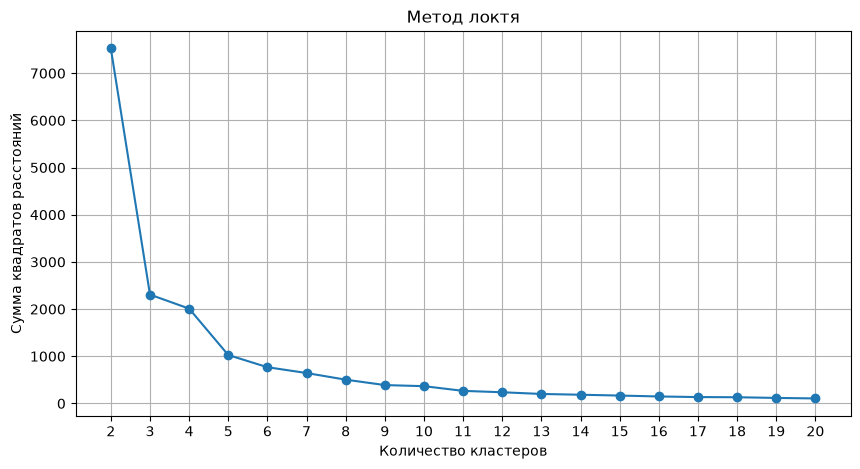

In [44]:
# График метода локтя
inertia = []
k_range = range(2, 21)
for n_clusters in k_range:
    pipe = get_kmeans_pipe(n_clusters)
    pipe.fit(df_c_train[CLASTER_COLS_COORDS])
    inertia.append(pipe['kmeans'].inertia_)

plt.figure(figsize=(10, 5))
plt.title('Метод локтя')
plt.xlabel('Количество кластеров')
plt.ylabel('Сумма квадратов расстояний')
plt.grid()
plt.plot(k_range, inertia, marker='o')
plt.xticks(k_range)
plt.show()

In [45]:
# Дополнительное оптимального количества кластеров.
# Доля улучшения относительно кластеризации с 2 кластерами.
_ = np.array(inertia)
((_[0] - _[1:]) / _[0]).round(2)


array([0.69, 0.73, 0.86, 0.9 , 0.91, 0.93, 0.95, 0.95, 0.96, 0.97, 0.97,
       0.98, 0.98, 0.98, 0.98, 0.98, 0.98, 0.99])

Скорость уменьшения ошибки начинает сильно падать при 9 кластерах, поэтому применим n_clusters=9

In [46]:
# Создание пайплайна для KMeans с 9 кластерами
kmeans_coords = get_kmeans_pipe(n_clusters=9)
kmeans_coords.fit(df_c_train[CLASTER_COLS_COORDS])

Pipeline(steps=[('scaler', StandardScaler()),
                ('kmeans', KMeans(n_clusters=9, random_state=1703))])

In [47]:
# центроиды кластеров
centers = kmeans_coords['scaler'].inverse_transform(kmeans_coords['kmeans'].cluster_centers_)

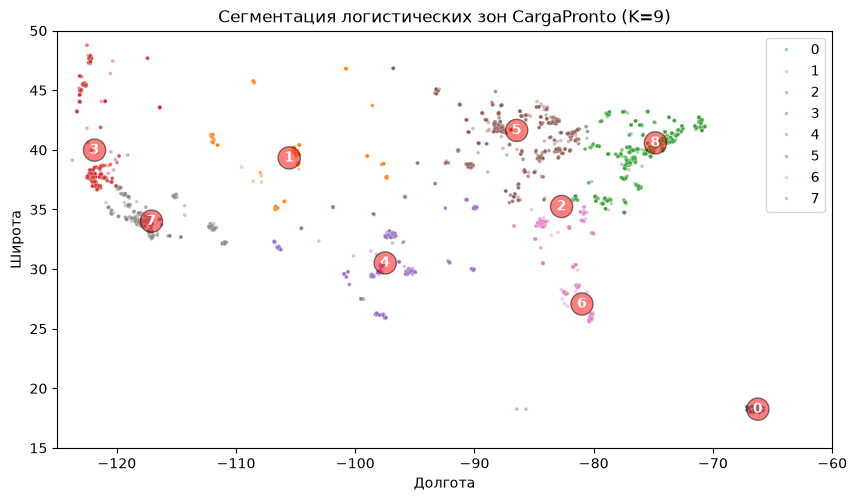

In [80]:
# Диаграмма рассеяния клиентов с разбивкой по кластерам
df_plot = df_c_train.copy()
df_plot['geo_cluster'] = kmeans_coords.predict(df_plot[CLASTER_COLS_COORDS])
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_plot,
    x='customer_lon', y='customer_lat',
    hue='geo_cluster',
    palette='tab10',
    s=7, alpha=0.4,
    legend='full',
)

# Добавим центры кластеров на scatterplot координат
for i, (lat, lon) in enumerate(centers):
    plt.text(
        lon, lat, str(i),
        fontsize=10, fontweight='bold',
        color='white',
        ha='center', va='center',
        bbox=dict(boxstyle='circle', facecolor='red', edgecolor='black', alpha=0.5,),
    )
plt.legend()
plt.xlim(-125, -60)
plt.ylim(15, 50)
plt.xlabel('Долгота')
plt.ylabel('Широта')
plt.title('Сегментация логистических зон CargaPronto (K=9)')
plt.gca().set_aspect('equal', adjustable='box')
plt.show()

**Промежуточный вывод**

- Координаты масштабированы (`StandardScaler`): разброс `lon` заметно больше, чем у `lat`.
- Scaler и K-Means обучены только на клиентах из train — без утечки в val/test.
- По методу локтя основной выигрыш набирается до K≈6 (~90% относительно K=2), к K=9 — ~95%, дальше прирост почти нулевой. Выбрано **K=9**.
- На карте зоны разделяются географически (запад/центр США, восток, Пуэрто-Рико и т.п.); признак `geo_cluster` готов к добавлению в модель.


##  Кластеризация по признакам профилей клиентов

1. Подготовим векторы признаков — используем пять ключевых показателей из датасета `df_customers.csv`: `recency`, `total_orders`, `total_sales`, `return_rate` и `avg_discount`.
2. Выполним предобработку данных и обеспечим защиту от утечек.
3. Используем метод локтя, чтобы найти математически обоснованную границу количества групп.
4. Проанализируем полученные кластеры: дадим статистическую характеристику и опишем самые яркие группы.
5. Визуализируем положение кластеров с помощью t-SNE.


In [49]:
CLASTER_COLS_NUMS = ['recency', 'total_orders', 'total_sales', 'return_rate', 'avg_discount']
df_c[CLASTER_COLS_NUMS].describe().T

,count,mean,std,min,25%,50%,75%,max
recency,20496.0,221.054791,199.321732,1.00,76.000000,160.000000,308.000000,1126.000000
total_orders,20496.0,3.182816,2.430372,1.00,1.000000,3.000000,5.000000,15.000000
total_sales,20496.0,1599.828742,1508.261915,8.47,252.880005,1293.685009,2619.100048,9436.610088
return_rate,20496.0,0.042867,0.156431,0.00,0.000000,0.000000,0.000000,1.000000
avg_discount,20496.0,0.101729,0.048269,0.00,0.076250,0.100000,0.123011,0.250000


K-Means считает евклидово расстояние, и оси с большим разбросом начинают влиять сильнее. В признаках датасета слишком большой разброс значений, поэтому требуется масштабирование, применим `StandardScaler`

Для защиты от утечки данных `KMeans` будем обучать только на данных тех пользователей, чьи заказы попали в тренировочную выборку

Перед применением `KMeans` определим оптимальное значение гиперпараметка `n_clusters` (количество групп) с помощью метода локтя:

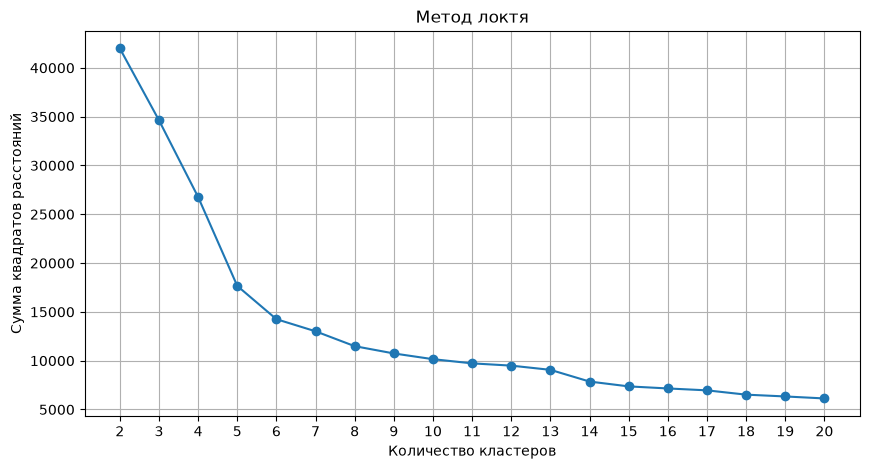

In [50]:
# График метода локтя
inertia = []
k_range = range(2, 21)
for n_clusters in k_range:
    pipe = get_kmeans_pipe(n_clusters)
    pipe.fit(df_c_train[CLASTER_COLS_NUMS])
    inertia.append(pipe['kmeans'].inertia_)

plt.figure(figsize=(10, 5))
plt.title('Метод локтя')
plt.xlabel('Количество кластеров')
plt.ylabel('Сумма квадратов расстояний')
plt.grid()
plt.plot(k_range, inertia, marker='o')
plt.xticks(k_range)
plt.show()

In [51]:
# Дополнительное оптимального количества кластеров.
# Доля улучшения относительно кластеризации с 2 кластерами.
_ = np.array(inertia)
((_[0] - _[1:]) / _[0]).round(2)

array([0.18, 0.36, 0.58, 0.66, 0.69, 0.73, 0.74, 0.76, 0.77, 0.77, 0.78,
       0.81, 0.82, 0.83, 0.83, 0.84, 0.85, 0.85])

Скорость уменьшения ошибки начинает сильно падать при 8 кластерах, поэтому применим n_clusters=8

In [52]:
# Создание пайплайна для KMeans с 8 кластерами
kmeans_nums = get_kmeans_pipe(n_clusters=8)
kmeans_nums.fit(df_c_train[CLASTER_COLS_NUMS])

Pipeline(steps=[('scaler', StandardScaler()),
                ('kmeans', KMeans(random_state=1703))])

In [53]:
# Статистика по кластерам
df_stats = df_c_train[CLASTER_COLS_NUMS].copy()
df_stats['cluster'] = kmeans_nums.predict(df_stats[CLASTER_COLS_NUMS])
df_stats.groupby('cluster').mean()

,recency,total_orders,total_sales,return_rate,avg_discount
cluster,,,,,
0,671.216681,2.665520,1384.933764,0.008259,0.099299
1,261.179736,5.543172,3015.366808,0.015574,0.102376
2,67.106333,1.028828,261.410974,0.000000,0.170748
3,124.992157,1.098039,342.039138,0.987435,0.100425
4,272.223573,3.351263,1651.979774,0.003264,0.101930
5,65.372925,1.015861,298.883726,0.000000,0.046973
6,226.816888,8.145161,4706.977880,0.041678,0.100751
7,309.869492,4.418644,2313.831787,0.319512,0.102071


**Характеристика кластеров**:

0. «Спящие» — давно не заказывали (recency ~670), мало заказов и скромная выручка.
1. «Лояльные середняки» — стабильная частота (~5–6 заказов) и хороший чек при низком return_rate.
2. «Новички со скидкой» — свежие разовые клиенты (≈1 заказ) с высокой avg_discount (~17%).
3. «Проблемные» — почти все заказы с возвратом/отменой (return_rate ≈ 0.99), высокий операционный риск.
4. «Умеренные постоянные» — средняя активность (~3 заказа), низкий return_rate, обычный discount.
5. «Новички без скидки» — свежие разовые клиенты при низкой avg_discount (~5%).
6. «VIP» — самые частые и денежные (~8 заказов, ~4700 sales), умеренный return_rate.
7. «Возвратные середняки» — средняя активность при заметно повышенном return_rate (~32%).


In [54]:
# Снижение размерности признаков
from sklearn.manifold import TSNE

# Инициализируем t-SNE
tsne = TSNE(n_components=2, random_state=RANDOM_STATE)
# Применяем t-SNE к масштабированным данным
df_tsne = tsne.fit_transform(
    kmeans_nums['scaler'].transform(df_c_train[CLASTER_COLS_NUMS])
)
# Преобразуем результат в DataFrame
df_tsne = pd.DataFrame(df_tsne, columns=['x', 'y'])

df_tsne['cluster'] = df_stats['cluster'].to_numpy()

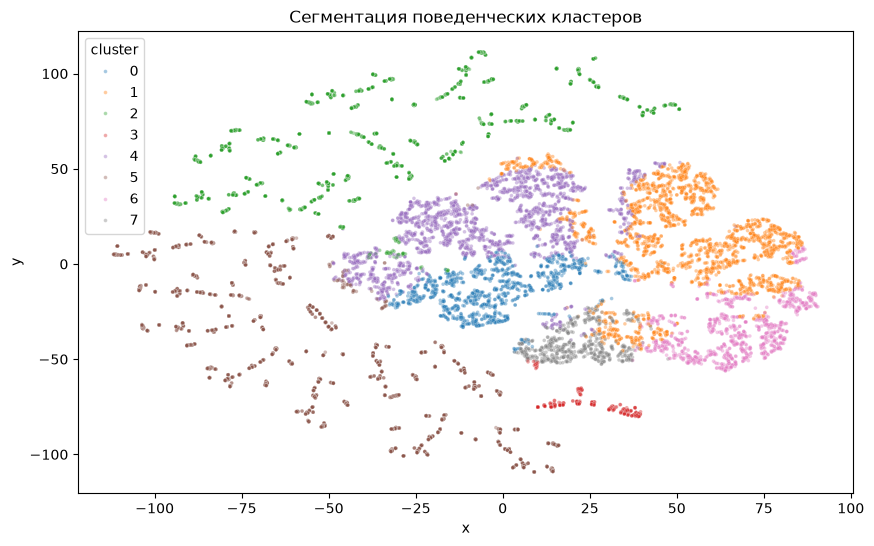

In [55]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_tsne,
    x='x', y='y',
    hue='cluster',
    palette='tab10',
    s=7, alpha=0.4,
)
plt.title('Сегментация поведенческих кластеров')
plt.show()

**Промежуточный вывод**

- RFM-признаки масштабированы (`StandardScaler`), K-Means обучен только на train-клиентах.
- По локтю выбран **K=8**: дальше inertia падает медленнее.
- Сегменты интерпретируемы — от VIP и лояльных до новичков и «проблемных» с return_rate ≈ 1.
- t-SNE показывает разделение кластеров в 2D; признак `beh_cluster` готов к добавлению в модель.


##  Обучение модели на новых признаках

1. Добавим результаты кластеризаций в данные для обучения моделей.
2. Обучим финальные версиии логистической регрессии и `CatBoostClassifier` на расширенном наборе данных.
3. Рассчитаем итоговые значения метрики ROC−AUC на валидационной выборке.
   

In [56]:
# Функция для добавления признаков кластеров в данные
def add_cluster_cols(df_c, df_o, kmeans_coords, kmeans_nums):
    df_clusters = pd.DataFrame({
        'customer_id': df_c['customer_id'],
        'geo_cluster': kmeans_coords.predict(df_c[CLASTER_COLS_COORDS]),
        'beh_cluster': kmeans_nums.predict(df_c[CLASTER_COLS_NUMS])
    })

    return df_o.merge(
        df_clusters,
        on='customer_id',
        how='left',
    )


In [57]:
# Функция для полной обработки данных
def get_processed_data(df_c, df_o, *, skip_cluster_cols=False):
    df_o = prepare_orders_data(df_o)
    df_c, df_o = remove_anomalies(df_c, df_o)
    
    if not skip_cluster_cols:
        df_o = add_cluster_cols(df_c, df_o, kmeans_coords, kmeans_nums)

    return df_c, df_o

In [58]:
# Пересборка данных с признаками кластеров
df_c, df_o = get_processed_data(*get_data())
df_o_train, df_o_val, df_o_test = split_orders(df_o)

df_o_train.head()


Файлы загружены из кеша


,order_id,customer_id,late_delivery_risk,shipping_mode,category_name,order_date,item_price,order_month,order_weekday,order_hour,geo_cluster,beh_cluster
0,180517,20755,0,Standard Class,Sporting Goods,2018-01-31 22:56:00,327.75,1,2,22,0,5
1,179254,19492,1,Standard Class,Sporting Goods,2018-01-13 12:27:00,327.75,1,5,12,0,5
3,179252,19490,0,Standard Class,Sporting Goods,2018-01-13 11:45:00,327.75,1,5,11,7,5
7,179248,19486,1,First Class,Sporting Goods,2018-01-13 10:21:00,327.75,1,5,10,6,2
8,179247,19485,1,Second Class,Sporting Goods,2018-01-13 10:00:00,327.75,1,5,10,0,2


In [59]:
# Указание новых списков признаков
num_cols = np.array(['item_price', 'order_hour', 'order_weekday', 'order_month'])
cat_cols = np.array(['shipping_mode', 'category_name', 'geo_cluster', 'beh_cluster'])
cols = np.concatenate([num_cols, cat_cols])

In [60]:
# Отделение признаков и целевой переменной
X_train = df_o_train[cols]
y_train = df_o_train[TARGET_COL]
X_val = df_o_val[cols]
y_val = df_o_val[TARGET_COL]

In [61]:
# Подбор гиперпараметров lr на расширенных признаках
studies['lr_cluster_new'] = run_study(objective_lr(
    X_train, y_train, X_val, y_val, num_cols, cat_cols,
))

[I 2026-08-02 00:04:34,404] A new study created in memory with name: no-name-66c3a616-b282-4a94-aba0-bce74500d4ba


  0%|          | 0/30 [00:00<?, ?it/s]

/Users/a1/Desktop/learning/ml_for_newbie/ml-identifying-risks-in-delivery/.venv/lib/python3.14/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


[I 2026-08-02 00:04:40,355] Trial 0 finished with value: 0.7418077479464569 and parameters: {'C': 10.253663514930077, 'l1_ratio': 0.19004822678449063}. Best is trial 0 with value: 0.7418077479464569.


/Users/a1/Desktop/learning/ml_for_newbie/ml-identifying-risks-in-delivery/.venv/lib/python3.14/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


...

[I 2026-08-02 00:07:05,914] Trial 27 finished with value: 0.741816734583328 and parameters: {'C': 10.419964893792224, 'l1_ratio': 0.8295584779451181}. Best is trial 21 with value: 0.7419674903249734.


/Users/a1/Desktop/learning/ml_for_newbie/ml-identifying-risks-in-delivery/.venv/lib/python3.14/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


[I 2026-08-02 00:07:11,907] Trial 28 finished with value: 0.741914485633436 and parameters: {'C': 0.5681662189571028, 'l1_ratio': 0.4034636367872759}. Best is trial 21 with value: 0.7419674903249734.


/Users/a1/Desktop/learning/ml_for_newbie/ml-identifying-risks-in-delivery/.venv/lib/python3.14/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


[I 2026-08-02 00:07:17,518] Trial 29 finished with value: 0.7418069278129298 and parameters: {'C': 11.065394919145671, 'l1_ratio': 0.14863638675862656}. Best is trial 21 with value: 0.7419674903249734.


In [62]:
# Подбор гиперпараметров catb на расширенных признаках
studies['catb_cluster_new'] = run_study(objective_catb(
    X_train, y_train, X_val, y_val, cat_cols,
))

[I 2026-08-02 00:07:17,528] A new study created in memory with name: no-name-16b1b5b1-bd77-4ea4-a3ea-c4ba48b811cc


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2026-08-02 00:07:19,662] Trial 0 finished with value: 0.7738655895638789 and parameters: {'learning_rate': 0.012660384042052011, 'depth': 4, 'iterations': 1100, 'l2_leaf_reg': 5.617043627161186}. Best is trial 0 with value: 0.7738655895638789.
[I 2026-08-02 00:07:21,490] Trial 1 finished with value: 0.7731363467808781 and parameters: {'learning_rate': 0.012838246111987457, 'depth': 6, 'iterations': 1500, 'l2_leaf_reg': 6.568347288991658}. Best is trial 0 with value: 0.7738655895638789.
[I 2026-08-02 00:07:24,177] Trial 2 finished with value: 0.7735868344110574 and parameters: {'learning_rate': 0.019278596454472413, 'depth': 5, 'iterations': 1600, 'l2_leaf_reg': 1.7701413143564555}. Best is trial 0 with value: 0.7738655895638789.
[I 2026-08-02 00:07:28,504] Trial 3 finished with value: 0.7745899305449498 and parameters: {'learning_rate': 0.020589008085720034, 'depth': 5, 'iterations': 900, 'l2_leaf_reg': 1.5358869932104204}. Best is trial 3 with value: 0.7745899305449498.
[I 2026-08-

In [63]:
# Сохранение результатов
results = {name: study.best_value for name, study in studies.items()}

In [64]:
# Добавление результатов работы моделей с изначальными параметрами и новыми признаками
model = add_preprocessor_to_lr(
    LogisticRegression(**studies['lr'].best_params, **lr_default_params),
    num_cols=num_cols,
    cat_cols=cat_cols,
)
model.fit(X_train, y_train)
results['lr_cluster_old'] = roc_auc_score(y_val, model.predict_proba(X_val)[:, 1])

_, auc = fit_catb(
    X_train, y_train, X_val, y_val,
    cat_cols=cat_cols,
    params=studies['catb'].best_params,
)

results['catb_cluster_old'] = auc

/Users/a1/Desktop/learning/ml_for_newbie/ml-identifying-risks-in-delivery/.venv/lib/python3.14/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


In [65]:
# Вывод топа моделей по ROC-AUC
results = pd.DataFrame(results, index=['ROC-AUC']).T.sort_values(by='ROC-AUC', ascending=False)
results

,ROC-AUC
catb_cluster_new,0.774969
catb_cluster_old,0.774342
catb,0.763309
lr_cluster_old,0.742011
lr_cluster_new,0.741967
lr,0.730569


**Промежуточный вывод**

- Кластеры (`geo_cluster`, `beh_cluster`) дают прирост ~**+0.011** и у LogReg, и у CatBoost — гипотеза о пользе профиля клиента подтверждается.
- Повторный Optuna почти не улучшает качество (разница < 0.001): важен сам факт новых признаков, а не переподбор гиперпараметров.
- Лучший вариант на val — **CatBoost + кластеры** (AUC ≈ 0.775). Его берём дальше как основной.


## Дополнительное задание — подбор лучшего количества кластеров

Рассмотрим количество кластеров как гиперпараметр всей системы и найдем ту «степень детализации», которая даст максимальный прирост ROC-AUC.

In [66]:
# Подготовка поиска гиперпараметров для catboost модели с кластеризацией
def objective_catb_with_kmeans(df_c_train, df_o_train, df_c_val, df_o_val):
    def objective(trial: optuna.trial.Trial) -> float:
        # Подготовка гиперпараметров
        params_catb = {
            'learning_rate': trial.suggest_float('catb__learning_rate', 0.01, 0.1, log=True),
            'depth': trial.suggest_int('catb__depth', 3, 10),
            'iterations': trial.suggest_int('catb__iterations', 500, 2000, step=100),
            'l2_leaf_reg': trial.suggest_float('catb__l2_leaf_reg', 1.0, 10.0, log=True),
        }

        params_kmeans_geo = {
            'n_clusters': trial.suggest_categorical('kmeans_geo__n_clusters', [4,8,12,16,20]),
        }

        params_kmeans_beh = {
            'n_clusters': trial.suggest_categorical('kmeans_beh__n_clusters', [6, 12, 18, 24, 30]),
        }

        # Подготовка кластеризации
        kmeans_geo = get_kmeans_pipe(n_clusters=params_kmeans_geo['n_clusters']).fit(df_c_train[CLASTER_COLS_COORDS])
        kmeans_beh = get_kmeans_pipe(n_clusters=params_kmeans_beh['n_clusters']).fit(df_c_train[CLASTER_COLS_NUMS])

        # Добавление признаков кластеров в данные
        df_o_train_cluster = add_cluster_cols(
            df_c_train,
            df_o_train,
            kmeans_geo,
            kmeans_beh,
        )
        
        df_o_val_cluster = add_cluster_cols(
            df_c_val,
            df_o_val,
            kmeans_geo,
            kmeans_beh,
        )
        
        num_cols = np.array(['item_price', 'order_hour', 'order_weekday', 'order_month'])
        cat_cols = np.array(['shipping_mode', 'category_name', 'geo_cluster', 'beh_cluster'])
        cols = np.concatenate([num_cols, cat_cols])

        _, auc = fit_catb(
            df_o_train_cluster[cols], df_o_train_cluster[TARGET_COL],
            df_o_val_cluster[cols], df_o_val_cluster[TARGET_COL],
            cat_cols, 
            params_catb
        )
        
        return auc

    return objective

In [67]:
# Свежая инициализация данных
df_c, df_o = get_processed_data(*get_data(), skip_cluster_cols=True)

df_o_train, df_o_val, df_o_test = split_orders(df_o)
df_c_train, df_c_val, df_c_test = split_customers(df_c, df_o_train, df_o_val, df_o_test)

Файлы загружены из кеша


In [68]:
# Запуск исследования
studies['catb_cluster_new_with_kmeans'] = run_study(objective_catb_with_kmeans(
    df_c_train, df_o_train, df_c_val, df_o_val,
))

[I 2026-08-02 00:09:01,787] A new study created in memory with name: no-name-257e9e34-acd5-43c8-ae8c-804e0335d514


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2026-08-02 00:09:09,234] Trial 0 finished with value: 0.7756773674374956 and parameters: {'catb__learning_rate': 0.012660384042052011, 'catb__depth': 4, 'catb__iterations': 1100, 'catb__l2_leaf_reg': 5.617043627161186, 'kmeans_geo__n_clusters': 16, 'kmeans_beh__n_clusters': 12}. Best is trial 0 with value: 0.7756773674374956.
[I 2026-08-02 00:09:14,702] Trial 1 finished with value: 0.7672410797448633 and parameters: {'catb__learning_rate': 0.019921068701090467, 'catb__depth': 4, 'catb__iterations': 1000, 'catb__l2_leaf_reg': 8.917961341578046, 'kmeans_geo__n_clusters': 16, 'kmeans_beh__n_clusters': 6}. Best is trial 0 with value: 0.7756773674374956.
[I 2026-08-02 00:09:16,342] Trial 2 finished with value: 0.7640573498919581 and parameters: {'catb__learning_rate': 0.014816154009158682, 'catb__depth': 4, 'catb__iterations': 1400, 'catb__l2_leaf_reg': 9.929653843898928, 'kmeans_geo__n_clusters': 12, 'kmeans_beh__n_clusters': 6}. Best is trial 0 with value: 0.7756773674374956.
[I 2026-0

In [69]:
# Функция для разбиения параметров оптимизации на объекты
def split_optuna_params(params: dict) -> dict:
    obj_to_params = {}
    for key, value in params.items():
        obj, param = key.split("__")
        obj_to_params.setdefault(obj, {})
        obj_to_params[obj][param] = value
    return obj_to_params

In [70]:
best_params = split_optuna_params(studies['catb_cluster_new_with_kmeans'].best_params)
best_params

{'catb': {'learning_rate': 0.028888985813555847,
  'depth': 7,
  'iterations': 800,
  'l2_leaf_reg': 1.0544396661143083},
 'kmeans_geo': {'n_clusters': 8},
 'kmeans_beh': {'n_clusters': 24}}

In [71]:
results.loc['catb_cluster_new_with_kmeans'] = studies['catb_cluster_new_with_kmeans'].best_value
results = results.sort_values(by='ROC-AUC', ascending=False)
results

,ROC-AUC
catb_cluster_new_with_kmeans,0.781870
catb_cluster_new,0.774969
catb_cluster_old,0.774342
catb,0.763309
lr_cluster_old,0.742011
lr_cluster_new,0.741967
lr,0.730569


**Промежуточный вывод**

Подбор числа кластеров вместе с гиперпараметрами CatBoost дал лучший результат на val:

- CatBoost baseline: **0.763**
- \+ кластеры (K_geo=9, K_beh=8): **0.775**
- \+ подбор K: **0.782** (`geo_k=8`, `beh_k=24`)

Прирост к фиксированным K небольшой (~+0.007), но стабильный. Оптимум не на максимальном K: слишком много кластеров дробит сегменты и ухудшает обобщение (в trials с крупным K AUC ниже).

Дальше на тест идёт **CatBoost** с `geo_k=8`, `beh_k=24` и найденными параметрами бустинга.


In [72]:
# Обучение финальных kmeans
kmeans_coords = get_kmeans_pipe(**best_params['kmeans_geo'])
kmeans_coords.fit(df_c_train[CLASTER_COLS_COORDS])

kmeans_nums = get_kmeans_pipe(**best_params['kmeans_beh'])
kmeans_nums.fit(df_c_train[CLASTER_COLS_NUMS])

Pipeline(steps=[('scaler', StandardScaler()),
                ('kmeans', KMeans(n_clusters=24, random_state=1703))])

In [73]:
# Подготовка финальной версии данных
df_c, df_o = get_processed_data(*get_data())
df_o_train, df_o_val, df_o_test = split_orders(df_o)
df_c_train, df_c_val, df_c_test = split_customers(df_c, df_o_train, df_o_val, df_o_test)

# Отделение признаков и целевой переменной
X_train = df_o_train[cols]
y_train = df_o_train[TARGET_COL]
X_val = df_o_val[cols]
y_val = df_o_val[TARGET_COL]
X_test = df_o_test[cols]
y_test = df_o_test[TARGET_COL]

df_o_train.head()

Файлы загружены из кеша


,order_id,customer_id,late_delivery_risk,shipping_mode,category_name,order_date,item_price,order_month,order_weekday,order_hour,geo_cluster,beh_cluster
0,180517,20755,0,Standard Class,Sporting Goods,2018-01-31 22:56:00,327.75,1,2,22,0,2
1,179254,19492,1,Standard Class,Sporting Goods,2018-01-13 12:27:00,327.75,1,5,12,0,2
3,179252,19490,0,Standard Class,Sporting Goods,2018-01-13 11:45:00,327.75,1,5,11,7,2
7,179248,19486,1,First Class,Sporting Goods,2018-01-13 10:21:00,327.75,1,5,10,6,10
8,179247,19485,1,Second Class,Sporting Goods,2018-01-13 10:00:00,327.75,1,5,10,0,4


In [74]:
# Обучение финальной версиии catboost

model, _ = fit_catb(
    X_train, y_train, X_val, y_val,
    cat_cols=cat_cols,
    params=best_params['catb'],
)

## Тестирование лучшей модели

На этом этапе убедимся, что выбранная модель сохраняет высокое качество на данных, которые она никогда не видела, и поймём, какие факторы стали решающими для прогноза.

1. Сделаем предсказание на тестовой выборке для лучшей модели, рассчитаем итоговый ROC-AUC и сравним его с целевым показателем 0.75.
2. Построим матрицу ошибок и определим, какой тип ошибок модель совершает чаще: пропускает реальные задержки или слишком часто выдаёт ложную тревогу.
3. Визуализируем важность признаков лучшей модели.
4. Проанализируем позиции признаков `geo_cluster` и `beh_cluster` в общем рейтинге: стали ли они ключевыми факторами или приоритетными остались базовые параметры заказа (цена, время).


In [75]:
# ROC-AUC на test
y_prob = model.predict_proba(X_test)[:, 1]
y_pred = model.predict(X_test)
print('Test ROC-AUC:', roc_auc_score(y_test, y_prob))

Test ROC-AUC: 0.7674446818423878


Модель соответствует целевому значению метрики ROC-AUC

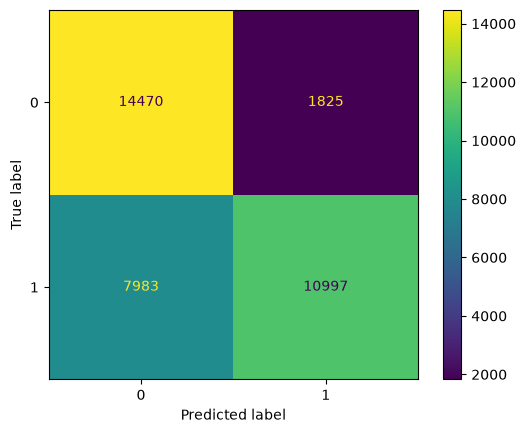

In [76]:
# Матрица ошибок
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)

plt.show()

In [77]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.64      0.89      0.75     16295
           1       0.86      0.58      0.69     18980

    accuracy                           0.72     35275
   macro avg       0.75      0.73      0.72     35275
weighted avg       0.76      0.72      0.72     35275



**Промежуточный вывод**

По матрице ошибок (порог 0.5):
- TN = 14 470, FP = 1 825, FN = 7 983, TP = 10 997
- модель чаще **пропускает реальные задержки** (FN), чем даёт ложные тревоги (FP)

По `classification_report` для класса задержки (1):
- precision ≈ **0.86** — если модель предупреждает о риске, она обычно права;
- recall ≈ **0.58** — находится только ~58% фактических задержек;
- f1 ≈ 0.69, accuracy ≈ 0.72

Для бизнеса это значит: ложных эскалаций мало, но часть проблемных заказов остаётся незамеченной. При необходимости можно снизить порог вероятности, чтобы поднять recall ценой большего числа FP.


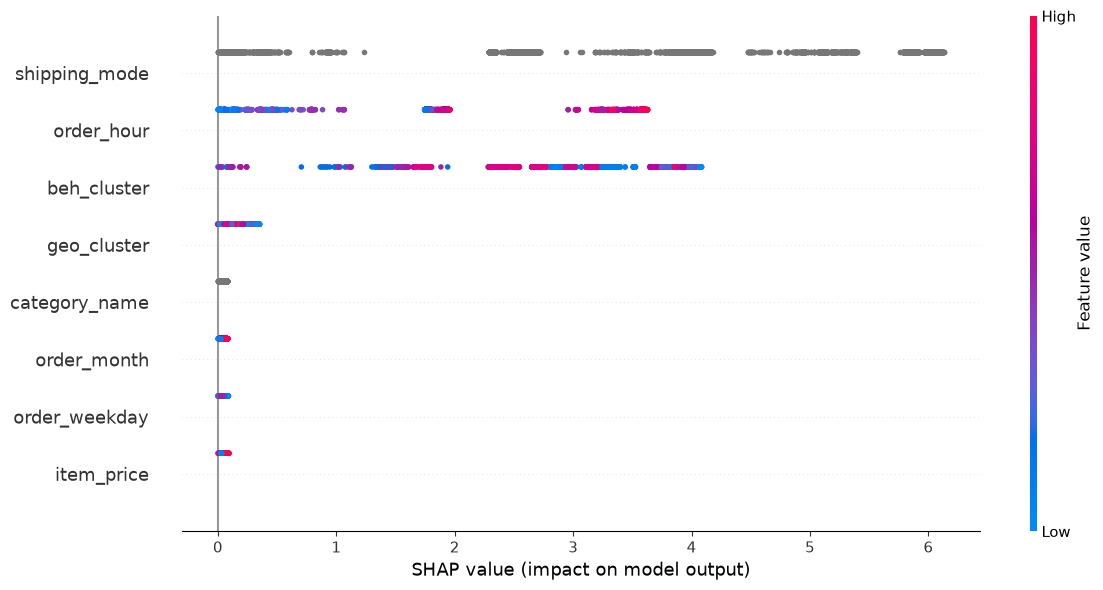

In [78]:
plt.figure(figsize=(12, 6))

explainer = shap.TreeExplainer(model)
shap_values = explainer(X_test)

shap.summary_plot(shap_values, X_test, show=False, plot_size=None, max_display=10)

**Промежуточный вывод**

По SHAP:
- сильнее всего на прогноз влияет `shipping_mode`, затем `order_hour`;
- `beh_cluster` и `geo_cluster` входят в топ-4 — сегментация клиентов полезна, поведение чуть важнее географии;
- `category_name`, время (месяц/день недели) и `item_price` почти не влияют.

Гипотеза подтверждается: профиль клиента добавляет сигнал, но самый сильный сигнал - режим доставки.


##  Выводы и рекомендации

### Результаты моделирования

Итоговая модель — **CatBoost** с признаками заказа и кластерами клиента (`geo_k=8`, `beh_k=24`).

| Модель | Выборка | ROC-AUC |
|---|---|---|
| LogReg baseline | val | 0.731 |
| CatBoost baseline | val | 0.763 |
| CatBoost + кластеры (фикс. K) | val | 0.775 |
| CatBoost + подбор K | val | **0.782** |
| **Итоговый CatBoost** | **test** | **0.767** |

Целевой порог **0.75 на тесте достигнут**. Относительно базового CatBoost прирост на val ≈ **+0.019** (0.763 → 0.782); на тесте качество остаётся выше порога, небольшой спад val→test ожидаем.

При пороге 0.5 модель чаще **пропускает задержки** (FN), чем даёт ложные тревоги (FP): precision класса 1 ≈ 0.86, recall ≈ 0.58.

### Эффективность сегментации

Гипотеза подтвердилась: профиль клиента влияет на риск задержки.
- Добавление `geo_cluster` и `beh_cluster` стабильно поднимает ROC-AUC (~+0.011 к baseline, ещё ~+0.007 после подбора K).
- По SHAP оба кластера в топ-4; **`beh_cluster` чуть важнее `geo_cluster`**.
- Главный драйвер всё же **`shipping_mode`**, затем `order_hour`; цена и категория товара почти не влияют.

Визуализации: карта geo-зон, t-SNE поведенческих сегментов, SHAP summary — в соответствующих разделах выше.

### Технический инсайт

Оптимальные числа кластеров: **geo_k = 8**, **beh_k = 24**.  
Слишком большое K дробит клиентов на мелкие нестабильные группы: в Optuna варианты с максимальным K чаще давали более низкий AUC. Scaler и K-Means обучались только на train-клиентах — без утечки в val/test.

### Бизнес-рекомендации для CargaPronto

1. В момент оформления заказа считать вероятность задержки; при высоком риске (например >0.7) поднимать приоритет сборки или предлагать более быстрый `shipping_mode`.
2. Отдельно сопровождать «проблемные» поведенческие сегменты (высокий `return_rate`) и сложные geo-зоны — заранее закладывать запас по SLA.
3. Учитывать час заказа: часть риска связана с `order_hour`, не только с адресом клиента.
4. Помнить про баланс ошибок: текущий порог даёт мало ложных тревог, но пропускает часть задержек — для минимизации штрафов SLA порог можно снизить, приняв больше ложных эскалаций.

**Итог:** сегментация клиентов усиливает прогноз, но операционно критичны режим доставки и своевременная реакция на высокий риск уже при создании заказа.
